In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import pickle # saving and loading trained model
from os import path

# importing required libraries for normalizing data
from sklearn import preprocessing
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder,LabelEncoder, MinMaxScaler, OneHotEncoder)
from sklearn.preprocessing import Normalizer, MaxAbsScaler , RobustScaler, PowerTransformer

# importing library for plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
benign=pd.read_csv('data/5.benign.csv')
g_c=pd.read_csv('data/5.gafgyt.combo.csv')
g_j=pd.read_csv('data/5.gafgyt.junk.csv')
g_s=pd.read_csv('data/5.gafgyt.scan.csv')
g_t=pd.read_csv('data/5.gafgyt.tcp.csv')
g_u=pd.read_csv('data/5.gafgyt.udp.csv')
m_a=pd.read_csv('data/5.mirai.ack.csv')
m_sc=pd.read_csv('data/5.mirai.scan.csv')
m_sy=pd.read_csv('data/5.mirai.syn.csv')
m_u=pd.read_csv('data/5.mirai.udp.csv')
m_u_p=pd.read_csv('data/5.mirai.udpplain.csv')

In [4]:
benign=benign.sample(frac=0.25,replace=False)
g_c=g_c.sample(frac=0.25,replace=False)
g_j=g_j.sample(frac=0.5,replace=False)
g_s=g_s.sample(frac=0.5,replace=False)
g_t=g_t.sample(frac=0.15,replace=False)
g_u=g_u.sample(frac=0.15,replace=False)
m_a=m_a.sample(frac=0.25,replace=False)
m_sc=m_sc.sample(frac=0.15,replace=False)
m_sy=m_sy.sample(frac=0.25,replace=False)
m_u=m_u.sample(frac=0.1,replace=False)
m_u_p=m_u_p.sample(frac=0.27,replace=False)

In [5]:
benign['type']='benign'
m_u['type']='mirai_udp'
g_c['type']='gafgyt_combo'
g_j['type']='gafgyt_junk'
g_s['type']='gafgyt_scan'
g_t['type']='gafgyt_tcp'
g_u['type']='gafgyt_udp'
m_a['type']='mirai_ack'
m_sc['type']='mirai_scan'
m_sy['type']='mirai_syn'
m_u_p['type']='mirai_udpplain'

In [6]:
data=pd.concat([benign,m_u,g_c,g_j,g_s,g_t,g_u,m_a,m_sc,m_sy,m_u_p],
               axis=0, sort=False, ignore_index=True)

In [7]:
#how many instances of each class
data.groupby('type')['type'].count()

type
benign            15538
gafgyt_combo      15345
gafgyt_junk       15449
gafgyt_scan       14648
gafgyt_tcp        15676
gafgyt_udp        15602
mirai_ack         15138
mirai_scan        14517
mirai_syn         16436
mirai_udp         15625
mirai_udpplain    15304
Name: type, dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169278 entries, 0 to 169277
Columns: 116 entries, MI_dir_L5_weight to type
dtypes: float64(115), object(1)
memory usage: 149.8+ MB


In [9]:
# distribution of attack classes
data.type.value_counts()

mirai_syn         16436
gafgyt_tcp        15676
mirai_udp         15625
gafgyt_udp        15602
benign            15538
gafgyt_junk       15449
gafgyt_combo      15345
mirai_udpplain    15304
mirai_ack         15138
gafgyt_scan       14648
mirai_scan        14517
Name: type, dtype: int64

In [10]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
data['type']= label_encoder.fit_transform(data['type'])

data['type'].unique()

array([ 0,  9,  1,  2,  3,  4,  5,  6,  7,  8, 10], dtype=int64)

In [11]:
X = data.drop(["type"],axis =1)
y = data["type"]

# CCMI Feature

In [12]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif

In [16]:
selector = SelectPercentile(mutual_info_classif, percentile=10)
X_reduced = selector.fit_transform(X, y)
X_reduced.shape

(169278, 12)

In [17]:
cols = selector.get_support(indices=True)
selected_columns = X.iloc[:,cols].columns.tolist()
selected_columns

['MI_dir_L0.1_weight',
 'MI_dir_L0.1_mean',
 'MI_dir_L0.1_variance',
 'MI_dir_L0.01_mean',
 'MI_dir_L0.01_variance',
 'H_L0.1_weight',
 'H_L0.1_mean',
 'H_L0.1_variance',
 'H_L0.01_mean',
 'H_L0.01_variance',
 'HH_jit_L0.1_mean',
 'HH_jit_L0.01_mean']

In [18]:
df = data[['MI_dir_L0.1_weight',
         'MI_dir_L0.1_mean',
         'MI_dir_L0.1_variance',
         'MI_dir_L0.01_mean',
         'MI_dir_L0.01_variance',
         'H_L0.1_weight',
         'H_L0.1_mean',
         'H_L0.1_variance',
         'H_L0.01_mean',
         'H_L0.01_variance',
         'HH_jit_L0.1_mean',
         'HH_jit_L0.01_mean',
             'type']]
df.to_csv('nbaiot_processed.csv')

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.2)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((135422, 12), (135422,), (33856, 12), (33856,))

In [20]:
ML_Model = []
accuracy = []
f1score = []
recall = []
precision = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))    
    f1score.append(round(d, 3))

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# MLP - sgd

In [22]:
from sklearn.neural_network import MLPClassifier
# instantiate the model 
clf = MLPClassifier(solver='sgd')

# fit the model 
clf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_hat = clf.predict(X_test)

ann_acc = accuracy_score(y_hat, y_test)
ann_prec = precision_score(y_hat, y_test,average='weighted')
ann_rec = recall_score(y_hat, y_test,average='weighted')
ann_f1 = f1_score(y_hat, y_test,average='weighted')

In [23]:
storeResults('MLP - sgd',ann_acc,ann_prec,ann_rec,ann_f1)

# MLP - lbfgs

In [24]:
from sklearn.neural_network import MLPClassifier
# instantiate the model 
clf = MLPClassifier(solver='lbfgs')

# fit the model 
clf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_hat = clf.predict(X_test)

ann1_acc = accuracy_score(y_hat, y_test)
ann1_prec = precision_score(y_hat, y_test,average='weighted')
ann1_rec = recall_score(y_hat, y_test,average='weighted')
ann1_f1 = f1_score(y_hat, y_test,average='weighted')

In [25]:
storeResults('MLP - lbfgs',ann1_acc,ann1_prec,ann1_rec,ann1_f1)

# MLP - adam

In [26]:
from sklearn.neural_network import MLPClassifier
# instantiate the model 
clf = MLPClassifier(solver='adam')

# fit the model 
clf.fit(X_train, y_train)

#predicting the target value from the model for the samples

y_hat = clf.predict(X_test)

ann2_acc = accuracy_score(y_hat, y_test)
ann2_prec = precision_score(y_hat, y_test,average='weighted')
ann2_rec = recall_score(y_hat, y_test,average='weighted')
ann2_f1 = f1_score(y_hat, y_test,average='weighted')

In [27]:
storeResults('MLP - adam',ann2_acc,ann2_prec,ann2_rec,ann2_f1)

# Voting Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

rfc = RandomForestClassifier()
parameters = {
    "n_estimators":[25],
    "max_depth":[20]
    
}

from sklearn.model_selection import GridSearchCV
forest = GridSearchCV(rfc,parameters,cv=10)

clf2 = DecisionTreeClassifier(random_state=100)

eclf1 = VotingClassifier(estimators=[('rf-parameter', forest), ('dt', clf2)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

In [38]:
storeResults('Voting Classifier',vot_acc,vot_prec,vot_rec,vot_f1)

# Stacking Classifier

In [30]:
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier

estimators = [('rf', forest),('dt', DecisionTreeClassifier(random_state=1))]

clf1 = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))


clf1.fit(X_train,y_train)

y_pred = clf1.predict(X_test)

stac_acc = accuracy_score(y_pred, y_test)
stac_prec = precision_score(y_pred, y_test,average='weighted')
stac_rec = recall_score(y_pred, y_test,average='weighted')
stac_f1 = f1_score(y_pred, y_test,average='weighted')

In [39]:
storeResults('Stacking Classifier',stac_acc,stac_prec,stac_rec,stac_f1)

# Comparison

In [40]:
#creating dataframe
import pandas as pd
import numpy as np
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'f1_score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                        
                      })

In [41]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,MLP - sgd,0.098,0.178,0.098,1.000
1,MLP - lbfgs,0.117,0.191,0.117,0.844
2,MLP - adam,0.524,0.529,0.524,0.883
3,Voting Classifier,0.995,0.995,0.995,0.995
4,Stacking Classifier,0.995,0.995,0.995,0.995


# Modelling

In [42]:
import joblib
filename = 'model_nbaiot.sav'
joblib.dump(eclf1, filename)


['model_nbaiot.sav']

# Graph

In [43]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

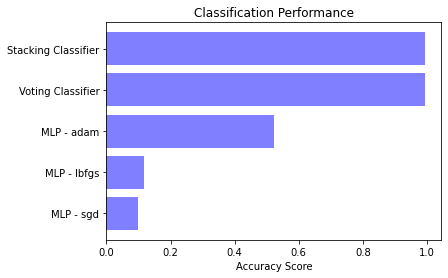

In [44]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

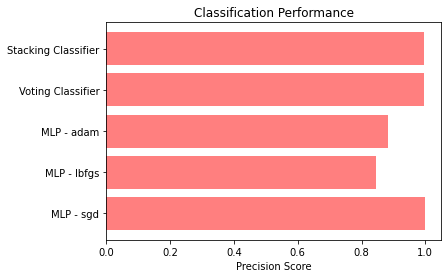

In [45]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

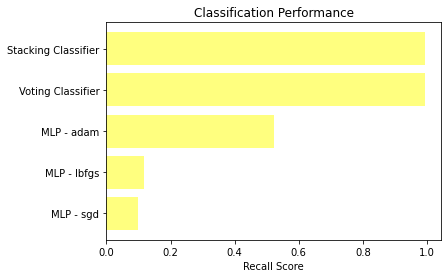

In [46]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 SCore

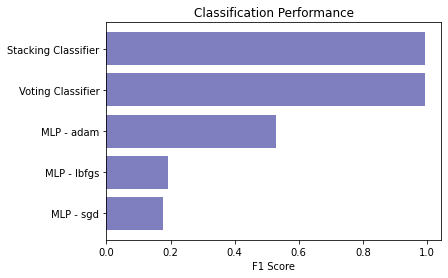

In [47]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()